In [162]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import robot_vlp.data_collection.experment_processing as p
import robot_vlp.data_collection.communication as c
import pickle

from robot_vlp.config import EXPERIMENT_DATA_DIR


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [163]:
import csv
import time



def read_vive_matrix(vive, n_readings = 10 ):
    readings = []
    for _ in range(n_readings):
        readings.append(np.array(vive.devices["tracker_1"].get_pose_matrix()))
        time.sleep(0.1)
    # mean_readings = np.mean(readings, axis = 0)
    return readings

def read_vive_radians(vive, n_readings = 10 ):
    readings = []
    for _ in range(n_readings):
        readings.append(np.array(vive.devices["tracker_1"].get_pose_radians()))
        time.sleep(0.1)
    # mean_readings = np.mean(readings, axis = 0)
    return readings

def read_vive_euler(vive, n_readings = 10 ):
    readings = []
    for _ in range(n_readings):
        readings.append(np.array(vive.devices["tracker_1"].get_pose_euler()))
        time.sleep(0.1)
    # mean_readings = np.mean(readings, axis = 0)
    return readings
    


def vive_robot_log_clear(log_file = 'robot_vive_data_log.csv' ):
    """Clears the log file and writes headers with a pipe delimiter."""
    with open(log_file, 'w') as f:
        f.write("vive_matrix|vive_radians|vive_euler|last_cmd\n")


def vive_robot_log_write(vive_matrix,vive_radians, vive_euler, cmd, log_file ):
    """Writes a single data point to the log file."""
    vive_matrix = str(vive_matrix).replace('\n', '')  # Remove newline characters
    vive_radians = str(vive_radians).replace('\n', '')  # Remove newline characters
    vive_euler = str(vive_euler).replace('\n', '')  # Remove newline characters


    last_cmd = str(cmd).replace('\n', '')    # Remove newline characters
    
    with open(log_file, 'a', newline='') as f:
        writer = csv.writer(f, delimiter='|', quotechar='"', quoting=csv.QUOTE_MINIMAL)
        writer.writerow([vive_matrix,vive_radians, vive_euler, cmd])


def take_vive_cal_point(point_no, log_file, vive, raw = True):
    vive_matrix = read_vive_matrix(vive)
    vive_radians = read_vive_radians(vive)
    vive_euler = read_vive_euler(vive)
    cmd = 'CAL:'+str(point_no)
    vive_robot_log_write(vive_matrix,vive_radians, vive_euler, cmd, log_file)

In [164]:
vive_robot_log_clear('vive_test.csv')

In [165]:
vive = c.vive_setup()

NameError: name 'vr' is not defined

In [166]:
c.read_vive(vive)

NameError: name 'vive' is not defined

In [167]:
take_vive_cal_point(12, 'vive_test.csv', vive)

NameError: name 'vive' is not defined

## Analysis

In [296]:
df= pd.read_csv('vive_test.csv', delimiter = '|')

def parse_mat(raw_string):
    # data = [a['m'] for a in eval(raw_string.replace('array','np.array'))]
    # return np.mean(data, axis = 0)

    return eval(raw_string.replace('array','np.array'))[0]['m']
def parse(raw_string):
    data = eval(raw_string.replace('array','np.array'))
    return np.mean(data, axis = 0)
df['vive_matrix'] = df['vive_matrix'].apply(parse_mat)
df['vive_euler'] = df['vive_euler'].apply(parse)
df['vive_radians'] = df['vive_radians'].apply(parse)







df['vive_data'] = df['vive_matrix']
transformer = ViveToRobotTransform()
transformer.derive_transform(df)



df['new_matrix'] = df['vive_matrix'].apply(lambda d: transformer.transform_pose(add_bottom_row(d)))



def extract_pose_y_up(pose_mat):

    import numpy as np
    import math
    # Translation components (x, y, z)
    x = pose_mat[0, 3]
    y = pose_mat[1, 3]
    z = pose_mat[2, 3]

    # Rotation matrix components
    R = pose_mat[:3, :3]
    yaw, pitch, roll = extract_euler_angles(R, sequence='zyx', degrees=True)
    return [x, y, z, yaw, pitch, roll]


new_vive = np.array(df['new_matrix'].apply(extract_pose_y_up).to_list())

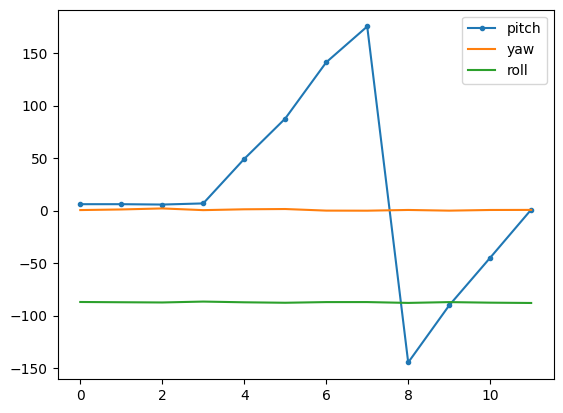

In [298]:
plt.plot(new_vive[:,3], label = 'pitch', marker = '.')
plt.plot(new_vive[:,4], label = 'yaw')
plt.plot(new_vive[:,5], label = 'roll')
plt.legend()

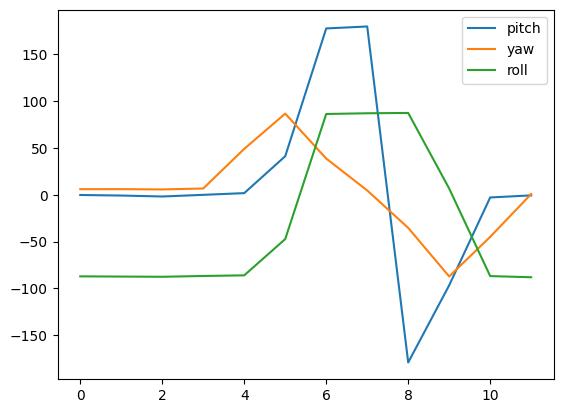

In [273]:
plt.plot(new_vive[:,3], label = 'pitch')
plt.plot(new_vive[:,4], label = 'yaw')
plt.plot(new_vive[:,5], label = 'roll')
plt.legend()

In [229]:
import numpy as np
from scipy.spatial.transform import Rotation as R

class ViveToRobotTransform:
    def __init__(self):
        self.transformation_matrix = None

    def derive_transform(self, df):
        """
        Derive the transformation matrix using pose matrices (4x4).
        """
        # Extract calibration points
        calibration_points = df[df['last_cmd'].str.startswith('CAL')].head(3)
        assert len(calibration_points) == 3, "Insufficient calibration points for alignment."

        # Known robot pose matrices for calibration points (identity rotation for simplicity in this example)
        robot_poses = [
            np.array([[1, 0, 0, 0],
                      [0, 1, 0, 0],
                      [0, 0, 1, 0.9],
                      [0, 0, 0, 1]]),  # CAL:1
            np.array([[1, 0, 0, 0],
                      [0, 1, 0, 0],
                      [0, 0, 1, 0],
                      [0, 0, 0, 1]]),  # CAL:2
            np.array([[1, 0, 0, 0.9],
                      [0, 1, 0, 0],
                      [0, 0, 1, 0],
                      [0, 0, 0, 1]])   # CAL:3
        ]

        # Vive pose matrices (ensure homogeneous 4x4 matrices)
        vive_poses = calibration_points['vive_data'].apply(np.array).to_list()

        # Compute the transformation matrix using point-to-point alignment
        robot_matrix = np.array(robot_poses)
        vive_matrix = np.array(vive_poses)

        # Solve for the transformation matrix
        self.transformation_matrix = self.align_poses(vive_matrix, robot_matrix)

    def align_poses(self, vive_poses, robot_poses):
        """
        Compute the best-fit transformation matrix between two sets of pose matrices.
        """
        # Compute centroids
        vive_centroid = np.mean([pose[:3, 3] for pose in vive_poses], axis=0)
        robot_centroid = np.mean([pose[:3, 3] for pose in robot_poses], axis=0)

        # Translate poses to origin (center them)
        vive_centered = [pose.copy() for pose in vive_poses]
        robot_centered = [pose.copy() for pose in robot_poses]

        for vc, rc in zip(vive_centered, robot_centered):
            vc[:3, 3] -= vive_centroid
            rc[:3, 3] -= robot_centroid

        # Compute rotation using Kabsch algorithm
        vive_stack = np.hstack([vc[:3, 3].reshape(-1, 1) for vc in vive_centered])
        robot_stack = np.hstack([rc[:3, 3].reshape(-1, 1) for rc in robot_centered])
        H = vive_stack @ robot_stack.T
        U, _, Vt = np.linalg.svd(H)
        rotation_matrix = U @ Vt

        # Check for reflection
        if np.linalg.det(rotation_matrix) < 0:
            Vt[-1, :] *= -1
            rotation_matrix = U @ Vt

        # Translation is the difference between centroids
        translation_vector = robot_centroid - rotation_matrix @ vive_centroid

        # Combine into a single 4x4 transformation matrix
        transformation_matrix = np.eye(4)
        transformation_matrix[:3, :3] = rotation_matrix
        transformation_matrix[:3, 3] = translation_vector

        return transformation_matrix

    def transform_pose(self, pose):
        """
        Transform a 4x4 pose matrix using the derived transformation.
        """
        if self.transformation_matrix is None:
            raise ValueError("Transformation not yet derived. Call `derive_transform` first.")

        return self.transformation_matrix @ pose




In [119]:
def add_bottom_row(matrix_3x4):
    """
    Add the bottom row [0, 0, 0, 1] to a 3x4 pose matrix to create a 4x4 pose matrix.
    """
    bottom_row = np.array([[0, 0, 0, 1]], dtype=matrix_3x4.dtype)
    matrix_4x4 = np.vstack((matrix_3x4, bottom_row))
    return matrix_4x4


In [ ]:



import numpy as np
from scipy.spatial.transform import Rotation as R

def extract_euler_angles(rotation_matrix, sequence='xyz', degrees=False):
  
    # Check if the matrix is 3x3
    if rotation_matrix.shape != (3, 3):
        raise ValueError("Rotation matrix must be 3x3.")
    
    # Convert the rotation matrix into a Rotation object
    r = R.from_matrix(rotation_matrix)

    # Extract Euler angles using the specified sequence
    euler_angles = r.as_euler(sequence, degrees=degrees)
    
    return euler_angles




In [ ]:
import numpy as np

def quaternion_from_matrix(m):
    """
    Convert a rotation matrix to a quaternion.
    
    Parameters:
    m (np.ndarray): A 3x4 or 3x3 rotation matrix.
    
    Returns:
    np.ndarray: Quaternion (w, x, y, z).
    """
    # Extract the elements from the matrix
    m0, m1, m2 = m[0, 0], m[0, 1], m[0, 2]
    m3, m4, m5 = m[1, 0], m[1, 1], m[1, 2]
    m6, m7, m8 = m[2, 0], m[2, 1], m[2, 2]
    
    # Compute the quaternion
    w = np.sqrt(1 + m0 + m4 + m8) / 2
    x = (m7 - m5) / (4 * w)
    y = (m2 - m6) / (4 * w)
    z = (m3 - m1) / (4 * w)
    
    return np.array([w, x, y, z])

def rotation_matrix_to_ypr(m):
    """
    Convert a rotation matrix to Euler angles (Heading, Pitch, Roll).
    
    Parameters:
    m (np.ndarray): A 3x4 or 3x3 rotation matrix.
    
    Returns:
    np.ndarray: Euler angles in the order (yaw, pitch, roll).
    """
    # Step 1: Convert rotation matrix to quaternion
    q = quaternion_from_matrix(m)
    
    # Step 2: Compute the values for gimbal lock check (test)
    test = q[1] * q[2] + q[3] * q[0]
    
    # Initialize the Euler angles
    yaw = pitch = roll = 0
    
    if test > 0.499:
        # Singularity at north pole (pitch = 90)
        yaw = 2 * np.arctan2(q[1], q[0])
        pitch = np.pi / 2
        roll = 0
    elif test < -0.499:
        # Singularity at south pole (pitch = -90)
        yaw = -2 * np.arctan2(q[1], q[0])
        pitch = -np.pi / 2
        roll = 0
    else:
        # General case (no gimbal lock)
        sqx = q[1] ** 2
        sqy = q[2] ** 2
        sqz = q[3] ** 2

        yaw = np.arctan2(2 * q[2] * q[0] - 2 * q[1] * q[3], 1 - 2 * sqy - 2 * sqz)
        pitch = np.arcsin(2 * test)
        roll = np.arctan2(2 * q[1] * q[0] - 2 * q[2] * q[3], 1 - 2 * sqx - 2 * sqz)
    
    # Return Euler angles (yaw, pitch, roll) in radians
    return np.array([yaw, pitch, roll])

# Example usage:

# Rotation matrix (3x3 matrix for the pure rotation part of the transformation matrix)
m = np.array([
    [-0.54274959,  0.00935239, -0.8398425 ],
    [ 0.00840071, -0.99982753, -0.01656294],
    [-0.83985256, -0.0160448 ,  0.54257741]
])

# Convert to Euler angles
euler_angles = rotation_matrix_to_ypr(m)

# Output the Euler angles (yaw, pitch, roll)
print(f"Yaw (Heading): {np.degrees(euler_angles[0])}°")
print(f"Pitch (Attitude): {np.degrees(euler_angles[1])}°")
print(f"Roll (Bank): {np.degrees(euler_angles[2])}°")


(-179.01280536608735, -57.12349168747078, 1.7484912562175015)